In [1]:
from frb.galaxies import galfit
from frb.frb import FRB
from frb.galaxies.frbgalaxy import FRBHost

from astropy.io import fits
from astropy import visualization as vis, units as u
from astropy.stats import sigma_clipped_stats
from astropy.wcs import WCS
from astropy.nddata import Cutout2D
from astropy.table import Table

import sep, numpy as np
import matplotlib.pyplot as plt

from photutils.isophote import Ellipse
from photutils.isophote import EllipseGeometry
from photutils import EllipticalAperture
from photutils.isophote import build_ellipse_model
from photutils.aperture import SkyEllipticalAperture, SkyEllipticalAnnulus, EllipticalAnnulus, EllipticalAperture
import os

In [2]:
frb = FRB.by_name("FRB190608").grab_host()
frb_pos = FRB.by_name("FRB190608").coord
posellipse = FRB.by_name("FRB190608").eellipse
posellipse

{'a': 0.19,
 'a_sys': 0.18,
 'b': 0.18,
 'b_sys': 0.18,
 'cl': 68.0,
 'cl_sys': 68.0,
 'theta': 0.0,
 'theta_sys': 0.0}

In [3]:
hdulist = fits.open("FRB190608_F160W_drz_sci.fits")
hdulist.info()

Filename: FRB190608_F160W_drz_sci.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     933   (2232, 1976)   float32   
  1  HDRTAB        1 BinTableHDU    559   7R x 275C   [9A, 3A, K, D, D, D, D, D, D, D, D, D, D, D, D, K, 2A, 9A, 7A, 18A, D, D, D, D, D, 3A, D, D, D, D, D, D, D, D, D, D, D, D, K, K, D, 3A, D, D, D, D, K, K, 8A, 23A, 11A, 18A, 4A, D, D, K, K, D, D, D, D, 23A, D, D, D, D, K, K, D, 3A, 8A, L, D, D, D, 23A, 1A, D, D, D, D, D, D, 12A, 12A, 8A, 23A, D, D, 10A, 10A, D, D, D, 2A, 3A, 3A, 4A, 8A, 7A, D, K, D, 6A, 9A, D, D, D, 4A, 18A, 3A, K, 5A, D, D, D, 8A, D, 3A, D, D, D, 3A, 1A, D, 23A, D, D, D, 3A, L, 1A, 4A, D, 3A, 6A, D, D, D, D, D, 23A, D, D, D, D, D, 1A, K, K, K, K, 8A, 23A, K, K, 10A, 7A, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, 13A, D, 24A, 23A, D, 1A, 1A, D, K, D, D, 1A, 1A, D, D, D, D, D, D, D, D, D, D, D, 4A, D, K, 23A, D, 8A, D, D, 13A, D, D, L, D, D, 5A, 9A, 2A, 4A, D, 1A, K, 1A, 1A, 1A, 1A, D, D, D, D,

the RADECSYS keyword is deprecated, use RADESYSa. [astropy.wcs.wcs]
/home/sunil/anaconda3/lib/python3.7/site-packages/astropy/visualization/stretch.py:285: RuntimeWarning: invalid value encountered in log
  np.log(values, out=values)
/home/sunil/anaconda3/lib/python3.7/site-packages/matplotlib/colors.py:527: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1


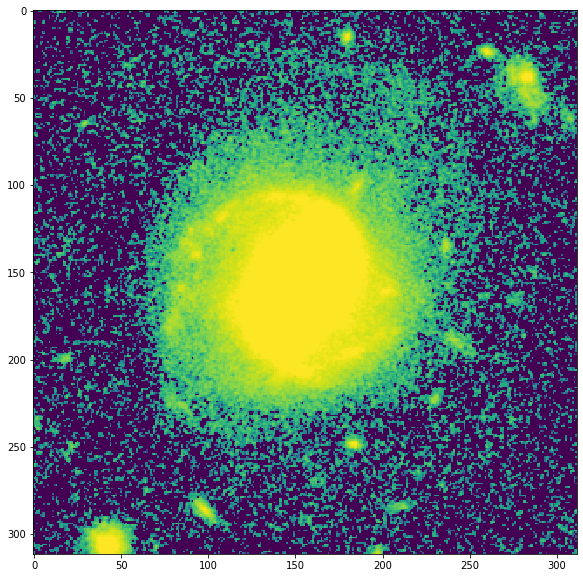

In [4]:
wcs = WCS(hdulist[0].header)
cutout = Cutout2D(hdulist[0].data,frb.coord, 20*u.arcsec, wcs)
_, med, std = sigma_clipped_stats(cutout.data)
cutout.data -= med # Subtract sky
fig = plt.figure(figsize=(10,10))
ax = plt.subplot()
plt.imshow(cutout.data, norm=vis.ImageNormalize(stretch=vis.LogStretch()), vmin =0, vmax = 10*std)
plt.show()

In [9]:
galfit.write_cutout(cutout, "FRB190608_cutout.fits", overwrite=True)

In [16]:
# Create segmentaiton map for badpix
objects, segmap = sep.extract(cutout.data.byteswap().newbyteorder(), thresh = 2*std,
                              deblend_cont = True, clean =True,
                              segmentation_map=True,minarea=25)

In [17]:
Table(objects)

thresh,npix,tnpix,xmin,xmax,ymin,ymax,x,y,x2,y2,xy,errx2,erry2,errxy,a,b,theta,cxx,cyy,cxy,cflux,flux,cpeak,peak,xcpeak,ycpeak,xpeak,ypeak,flag
float64,int64,int64,int64,int64,int64,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64,int64,int64,int64,int64
0.025090688839554787,38,37,177,182,12,19,179.56239210108137,14.869767791422962,2.017012013141617,2.904895478813728,-0.42809493513663366,0.0,0.0,0.0,1.754331350326538,1.3580238819122314,-1.1871823072433472,0.5117907524108887,0.3553615212440491,0.15084537863731384,2.0292677879333496,2.12541127204895,0.10157131403684616,0.12399095296859741,180,15,180,15,0
0.025090688839554787,42,41,256,264,21,26,260.13403259651204,23.49479979285431,3.771978039898638,1.9344262451886243,0.7619544060109451,0.0,0.0,0.0,2.0116710662841797,1.2882485389709473,0.3461809754371643,0.28803083300590515,0.5616373419761658,-0.22690589725971222,2.3355493545532227,2.424126625061035,0.10462586581707001,0.12498915195465088,260,23,260,23,0
0.025090688839554787,382,363,271,293,29,56,282.2086670329495,40.87895534426987,20.65502507229452,41.172228780214425,13.340400727583699,0.0,0.0,0.0,6.909582614898682,3.752988815307617,1.113169550895691,0.0612274594604969,0.03071620687842369,-0.039677172899246216,19.772483825683594,20.05370330810547,0.16814091801643372,0.18989592790603638,284,38,284,38,0
0.025090688839554787,49,45,237,246,184,193,241.2941097247934,188.77310007980685,6.0064488213770275,4.658099378129474,3.5969723770343798,0.0,0.0,0.0,2.9986464977264404,1.29331636428833,0.6927587985992432,0.30970528721809387,0.39935365319252014,-0.4783072769641876,1.6338709592819214,1.7451562881469727,0.04773292690515518,0.05439314246177673,241,189,241,189,0
0.025090688839554787,15375,14995,74,227,86,227,153.09062417740432,156.24278658179935,316.9904546705002,344.1625330818015,-32.49420115051544,0.0,0.0,0.0,19.125808715820312,17.185935974121094,-0.9834068417549133,0.003185499459505081,0.0029340002220124006,0.0006015196559019387,4819.32275390625,4821.451171875,28.784948348999023,32.64307403564453,154,156,154,156,0
0.025090688839554787,46,41,179,187,246,251,183.3556391680567,248.39576096967878,4.022756831347085,1.9298162836864847,0.2974313948517704,0.0,0.0,0.0,2.0159871578216553,1.3741792440414429,0.13846039772033691,0.25145116448402405,0.5241571068763733,-0.07750941812992096,2.63551664352417,2.737959384918213,0.1097484827041626,0.12686878442764282,184,248,183,248,0
0.025090688839554787,84,79,93,103,280,293,97.81183829508589,286.1271016719701,6.602698303751001,7.153860360617124,4.359170731496384,0.0,0.0,0.0,3.3535282611846924,1.5844261646270752,0.8169655203819275,0.25339174270629883,0.23386943340301514,-0.3088061213493347,4.178059101104736,4.316116809844971,0.1027175635099411,0.11600041389465332,98,286,98,286,0
0.025090688839554787,374,364,31,55,293,311,42.59021068396864,304.5363763647804,24.88600543467237,16.841122265935525,1.5836219311682953,0.0,0.0,0.0,5.018616676330566,4.067015171051025,0.18753035366535187,0.040425121784210205,0.05973591282963753,-0.007602594327181578,35.282466888427734,35.9246826171875,0.3407759666442871,0.3748054504394531,42,307,43,307,2


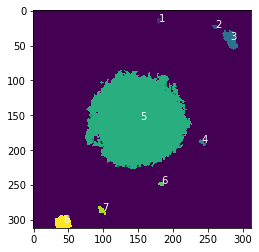

In [18]:
plt.imshow(segmap)
for idx, obj in enumerate(objects):
    plt.annotate(str(idx+1),(obj['x'],obj['y']),color="white")

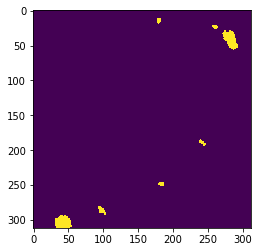

In [19]:
maskout = segmap==5
newsegmap = segmap.copy()
newsegmap[maskout] = 0

# bad pixels should have value of 1
newsegmap[newsegmap>0] = 1
plt.imshow(newsegmap)

# save segmap as a fits file
hdu = fits.PrimaryHDU(newsegmap, cutout.wcs.to_header())
hdulist = fits.HDUList([hdu])
hdulist.writeto("badpix_190608.fits", overwrite=True)

In [10]:
psfhdus = fits.open("FRB190608_f160w_psf.fits")
psfhdus[0].header

SIMPLE  =                    T                                                  
BITPIX  =                  -32                                                  
NAXIS   =                    2                                                  
NAXIS1  =                  414                                                  
NAXIS2  =                  414                                                  
EXTEND  =                    F                                                  
CREATED = 'Fri Aug  7 18:02:37 2020'  / Time and date file was created          
INSTRUME= 'WFC3_IR'            / Simulated instrument                           
FOCUS   =              -0.0631 / PSF RMS focus (waves @ 547 nm)                 
X_COMA  =              -0.0262 / PSF RMS X-coma (waves @ 547 nm)                
Y_COMA  =               0.0501 / PSF RMS Y-coma (waves @ 547 nm)                
X_ASTIG =              -0.0509 / PSF RMS 0d astig (waves @ 547 nm)              
Y_ASTIG =              -0.00

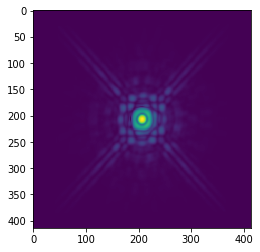

In [16]:
plt.imshow(psfhdus[0].data, norm=vis.ImageNormalize(stretch=vis.LogStretch()))
plt.show()

In [17]:
std

0.0028619564

In [18]:
help(galfit.run)

Help on function run in module frb.galaxies.galfit:

run(imgfile: str, psffile: str, **kwargs) -> int
    Run galfit. 
    
    Args:
        imgfile (str): path to the image fits file.
        psffile (str): path to the PSF model fits file.
    
    Valid kwargs:
        outdir (str): Name of output directory. Default
            value is 'galfit_out` in the current directory.
        configfile (str, optional): path to configuration file to
            be created via this function. Defaults to `<outdir>/galfit.feedme`.
        outfile (str, optional): path to GALFIT's output fits file.
            Defaults to `<outdir>/out.fits`
        finesample (int, optional): The PSF fine-sampling factor.
            Assumes no fine-sampling (i.e. a factor of 1) by default.
        badpix (str, optional): File containing a list of bad pixels.
            Assumes all pixels a re fine by default.
        constraints (str, optional): File containing fit parameter
            bounds. Check out this 

In [20]:
galfit.run(imgfile="FRB190608_cutout.fits",
           psffile="FRB190608_f160w_psf.fits", cdkfile= "190608_CDK.txt",outdir="F160W_190608",finesample=9,
           badpix = "badpix_190608.fits",
           r_e = 50, n = 4, axis_ratio = 0.6, convobox = (300, 300))

/home/sunil/Python/FRB/frb/galaxies/galfit.py:154: UserWarning: Creating a configuration file here
  warnings.warn("Creating a configuration file here")
/home/sunil/Python/FRB/frb/galaxies/galfit.py:176: UserWarning: Creating output file here
  warnings.warn("Creating output file here")
/home/sunil/Python/FRB/frb/galaxies/galfit.py:196: UserWarning: Using full region to fit. May fail if other objects in the region aren't masked.
  warnings.warn("Using full region to fit. May fail if other objects in the region aren't masked.")
/home/sunil/Python/FRB/frb/galaxies/galfit.py:230: UserWarning: No guess given for integrated magnitude. Proceeding with sum within region.
  warnings.warn("No guess given for integrated magnitude. Proceeding with sum within region.")


0

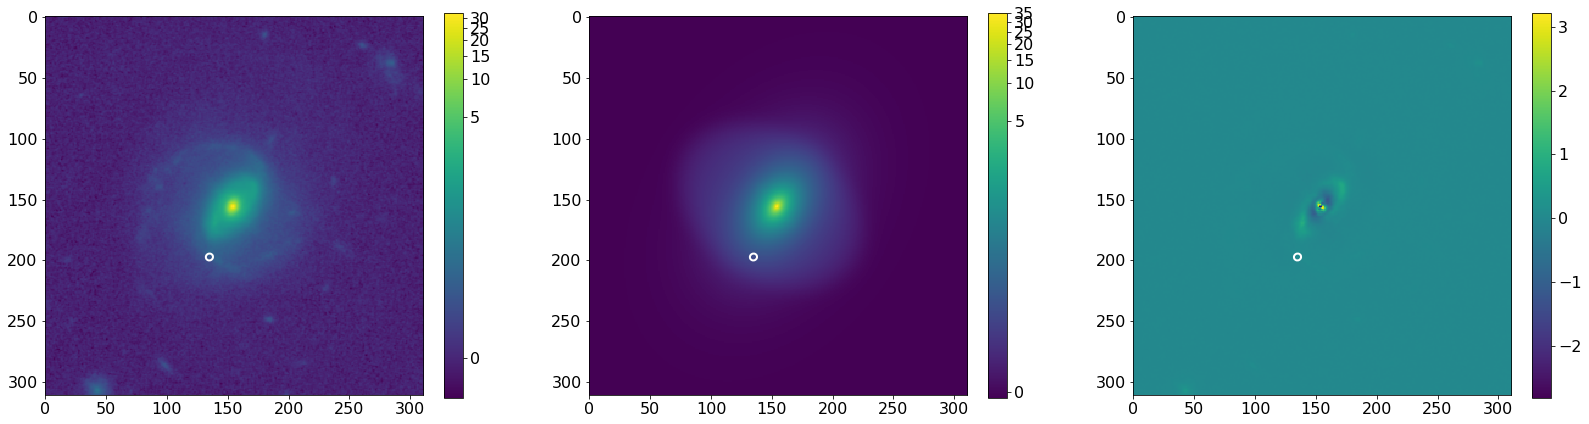

In [5]:
plt.rcParams['font.size'] = 16
hdulist = fits.open("F160W_190608/out.fits")
skyerr_ell = SkyEllipticalAperture(frb_pos, posellipse['a']*u.arcsec, posellipse['b']*u.arcsec,theta=posellipse['theta']*u.deg)
err_ell = skyerr_ell.to_pixel(WCS(hdulist[1].header))
apermask = err_ell.to_mask()
fig, axs = plt.subplots(nrows=1,ncols=3,figsize=(27,9),gridspec_kw={'wspace':0.3})
labels = ['HST WFC3 F160W','Fit','Residuals']
for (num,hdu),ax,label in zip(enumerate(hdulist[1:4]),axs,labels):
    if num==2:
        norm = vis.ImageNormalize(stretch=vis.LinearStretch())
    else:
        norm = vis.ImageNormalize(stretch=vis.LogStretch())
    im = ax.imshow(hdu.data, norm=norm)
    err_ell.plot(ax, color="w", lw=2)
    fig.colorbar(im, ax=ax, fraction=0.046)

In [6]:
#os.chdir("/home/sunil/Desktop/FRB/GALFIT/F160W_30mas")
os.chdir("/home/sunil/Desktop/FRB/GALFIT/F160W_30mas/F160W_190608")
fitlog = galfit.read_fitlog("fit.log", "galfit.10", twocomponent=True)
fit_tab = galfit.pix2coord(fitlog, WCS(hdulist[1].header), table=True,multicomponent=True)
os.chdir("/home/sunil/Desktop/FRB/GALFIT/F160W_30mas")
fit_tab

ra,ra_err,dec,dec_err,mag,mag_err,reff_ang,reff_ang_err,n,n_err,b/a,b/a_err,PA,PA_err
float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
334.02047222954207,0.014762595674010132,-7.89875529678143,0.016046299645663186,18.09,0.02,3.3511092180002997,0.02695778340471415,0.15,0.01,0.73,0.01,54.12,0.86
334.02042952092626,0.0012837039716530549,-7.898847887399037,0.0012837039716530549,15.9,0.0,0.8684257368232916,0.0044929639007856926,2.65,0.01,0.69,0.0,33.74,0.36


In [7]:
fitloghdu = fits.BinTableHDU(fit_tab,name="FITPARAMS")
for idx in [2,3]:
    hdulist[idx].header.insert('OBJECT',('PCOUNT',0))
    hdulist[idx].header.insert('OBJECT',('GCOUNT',1))
hdulist.append(fitloghdu)
hdulist.writeto("F160W_190608/HG190608_galfit.fits", overwrite=True)

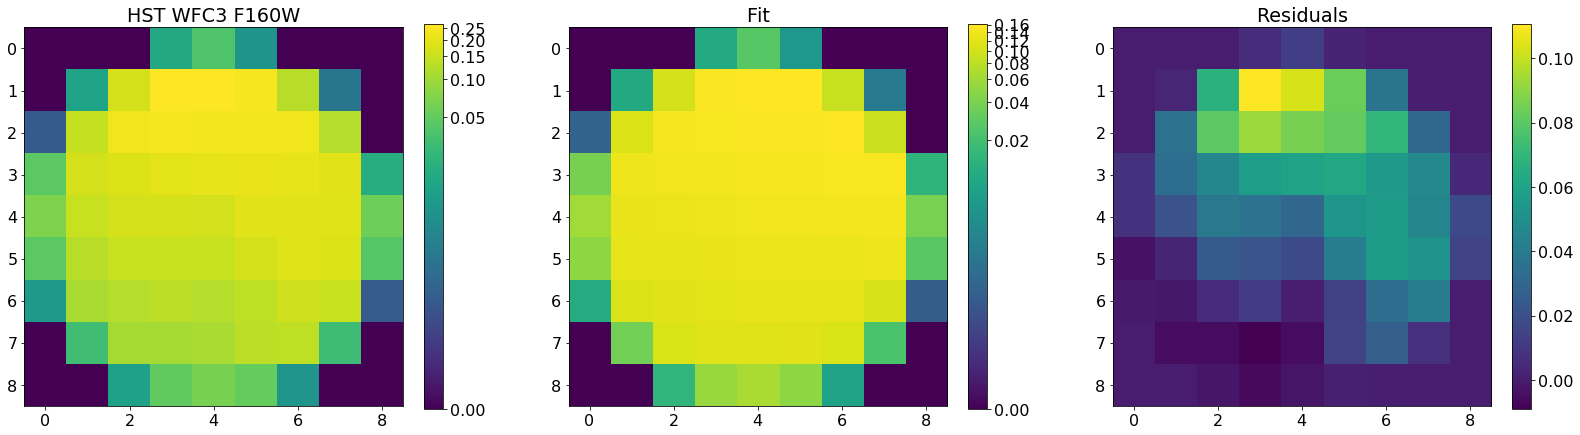

In [7]:
skyerr_ell = SkyEllipticalAperture(frb_pos,0.25*u.arcsec, 0.25*u.arcsec,theta=0*u.deg)
err_ell = skyerr_ell.to_pixel(WCS(hdulist[1].header))
apermask = err_ell.to_mask()

fig, axs = plt.subplots(nrows=1,ncols=3,figsize=(27,9),gridspec_kw={'wspace':0.3})
labels = ['HST WFC3 F160W','Fit','Residuals']
for (num,hdu),ax,label in zip(enumerate(hdulist[1:4]),axs,labels):
    if num==2:
        norm = vis.ImageNormalize(stretch=vis.LinearStretch())
    else:
        norm = vis.ImageNormalize(stretch=vis.LogStretch())
    im = ax.imshow(apermask.multiply(hdu.data), norm=norm)
    #err_ell.plot(ax, color="w", lw=2)
    fig.colorbar(im, ax=ax, fraction=0.046)
    ax.set_title(label)

In [9]:
npix = np.sum(apermask.data)
resid_mask = apermask.multiply(hdulist[3].data)
img_mask = apermask.multiply(hdulist[2].data)
resid_flux = np.sum(resid_mask)
resid_flux_err = np.sqrt(npix)*np.std(resid_mask[img_mask!=0])
resid_flux, resid_flux_err

(1.950800637555835, 0.21007024933718663)

In [10]:
inhdus = fits.open("FRB190608_F160W_drz_sci.fits")
inhdr = inhdus[0].header
zpt = -2.5*np.log10(inhdr['PHOTFLAM'])-5*np.log10(inhdr['PHOTPLAM'])-2.408
resid_mag =  zpt -2.5*np.log10(resid_flux)
resid_mag_err = zpt - 2.5*np.log10(5*resid_flux_err)
resid_mag, resid_mag_err

(25.220694981970258, 25.89289081598302)

In [12]:
from photutils.isophote import Ellipse
from photutils.isophote import EllipseGeometry
from photutils import EllipticalAperture
from photutils.isophote import build_ellipse_model

geometry = EllipseGeometry(x0=150, y0=150, sma=50, eps=0.6, pa=-28.9*np.pi/180.)
ellipse = Ellipse(cutout.data, geometry)
isolist = ellipse.fit_image(maxsma=150,sclip=3.,nclip=10,step = 0.05)
model_image = build_ellipse_model(cutout.data.shape, isolist)
residual = cutout.data - model_image

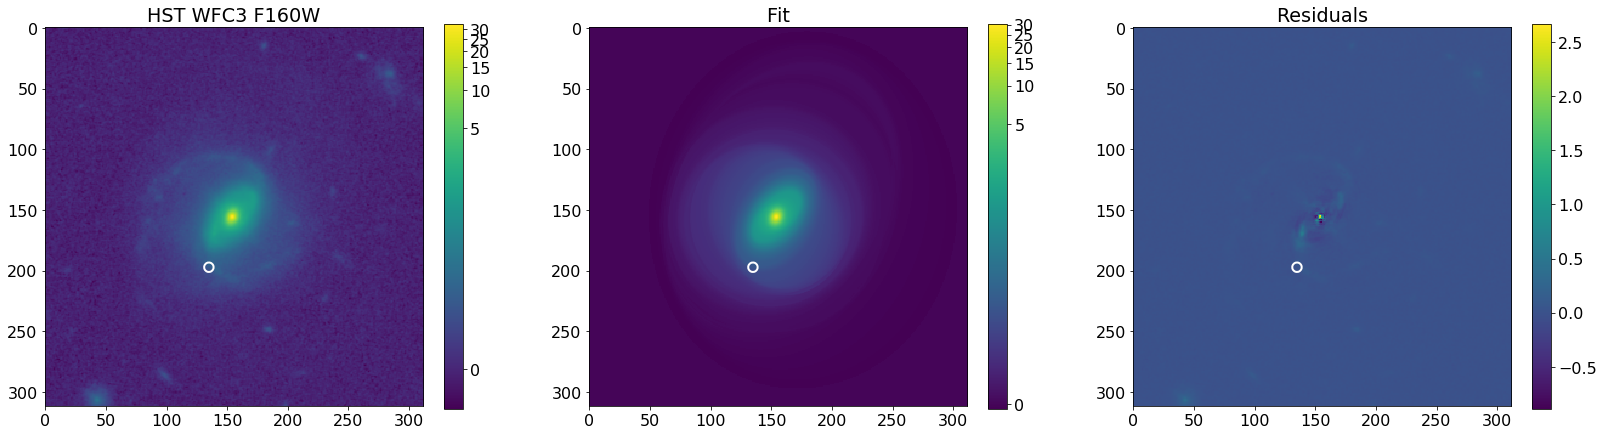

In [13]:
ell_ims = [cutout.data, model_image, residual]
fig, axs = plt.subplots(nrows=1,ncols=3,figsize=(27,9),gridspec_kw={'wspace':0.3})
for pic, ax, label in zip(ell_ims,axs, labels):
    _, med, std = sigma_clipped_stats(pic)
    if np.all(pic == residual):
        im = ax.imshow(pic, norm=vis.ImageNormalize(stretch=vis.LinearStretch()))
    else:
        im = ax.imshow(pic, norm=vis.ImageNormalize(stretch=vis.LogStretch()))
    fig.colorbar(im, ax=ax, fraction=0.046)
    ax.set_title(label)
    err_ell.plot(ax, color="w", lw=2)

In [14]:
data_hdu = fits.PrimaryHDU(cutout.data, header=hdulist[1].header)
model_hdu = fits.ImageHDU(model_image, header=hdulist[1].header)
resid_hdu = fits.ImageHDU(residual, header=hdulist[1].header)
elli_hdulist = fits.HDUList([data_hdu, model_hdu, resid_hdu])
elli_hdulist.writeto("F160W_190608/isophote.fits", overwrite=True)

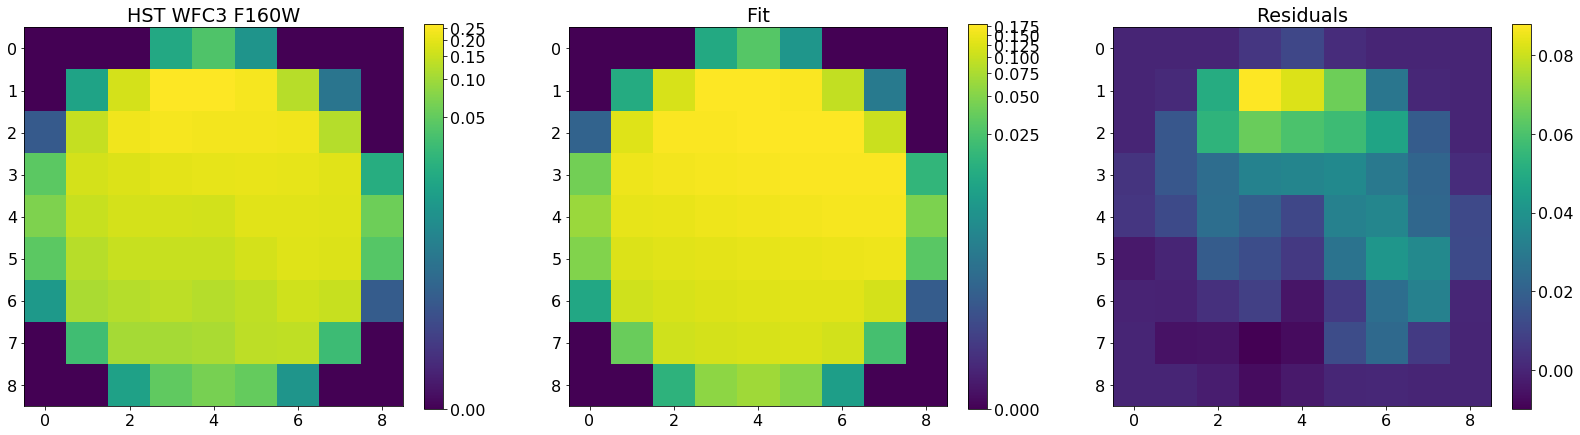

In [15]:
ell_ims = [cutout.data, model_image, residual]
fig, axs = plt.subplots(nrows=1,ncols=3,figsize=(27,9),gridspec_kw={'wspace':0.3})
for pic, ax, label in zip(ell_ims,axs, labels):
    _, med, std = sigma_clipped_stats(pic)
    if np.all(pic==residual):
        im = ax.imshow(apermask.multiply(pic), norm=vis.ImageNormalize(stretch=vis.LinearStretch()))
    else:
        im = ax.imshow(apermask.multiply(pic), norm=vis.ImageNormalize(stretch=vis.LogStretch()))
    fig.colorbar(im, ax=ax, fraction=0.046)
    ax.set_title(label)

In [18]:
resid_mask = apermask.multiply(residual)
img_mask = apermask.multiply(model_image)
resid_flux = np.sum(resid_mask)
resid_flux_err = np.sqrt(npix)*np.std(resid_mask[img_mask!=0])
resid_flux, resid_flux_err

(1.2685631648368234, 0.15384424301857672)

In [19]:
inhdus = fits.open("FRB190608_F160W_drz_sci.fits")
inhdr = inhdus[0].header
zpt = -2.5*np.log10(inhdr['PHOTFLAM'])-5*np.log10(inhdr['PHOTPLAM'])-2.408
resid_mag =  zpt -2.5*np.log10(resid_flux)
resid_mag_err = zpt - 2.5*np.log10(5*resid_flux_err)
resid_mag, resid_mag_err

(25.687946962427368, 26.231099070213023)